In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.6 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


CNN

Số class: 36
Các nhãn: ['class_0', 'class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9', 'class_A', 'class_B', 'class_C', 'class_D', 'class_E', 'class_F', 'class_G', 'class_H', 'class_I', 'class_J', 'class_K', 'class_L', 'class_M', 'class_N', 'class_O', 'class_P', 'class_Q', 'class_R', 'class_S', 'class_T', 'class_U', 'class_V', 'class_W', 'class_X', 'class_Y', 'class_Z']


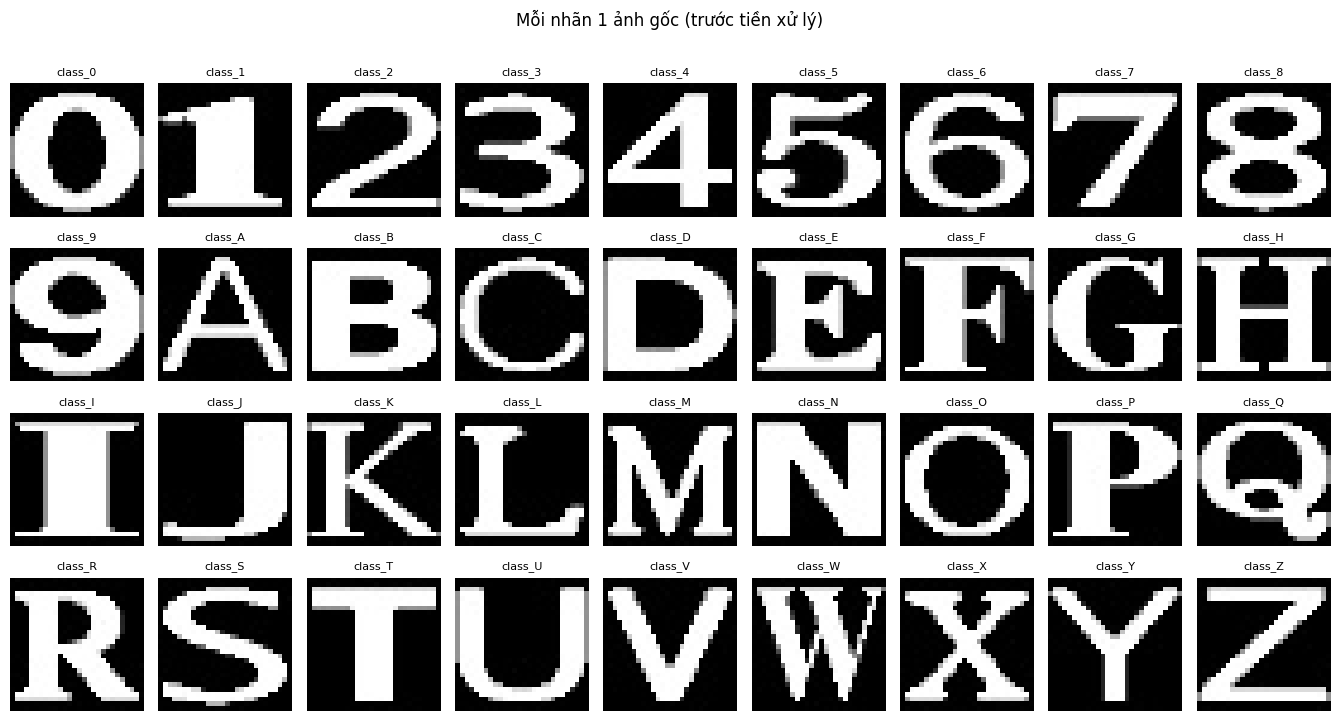

In [7]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# ── Dataset path ──
path = '/kaggle/input/datasets/foolishboi/alpr-character-train/data'
train_path = path + '/train'

# ── Lấy danh sách nhãn ──
class_names = sorted(os.listdir(train_path))
num_classes = len(class_names)

print(f"Số class: {num_classes}")
print(f"Các nhãn: {class_names}")

# ── Lấy ngẫu nhiên mỗi nhãn 1 ảnh ──
collected = {}
for cls in class_names:
    cls_folder = os.path.join(train_path, cls)
    images_in_folder = [
        f for f in os.listdir(cls_folder)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    if images_in_folder:
        chosen = random.choice(images_in_folder)
        collected[cls] = os.path.join(cls_folder, chosen)

# ── Hiển thị ──
cols = 9
rows = (num_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.8))
axes = axes.flatten()

for idx, cls in enumerate(class_names):
    if cls in collected:
        img = Image.open(collected[cls]).convert('RGB')
        axes[idx].imshow(np.array(img))
        axes[idx].set_title(cls, fontsize=8)
    axes[idx].axis('off')

# Ẩn ô trống thừa
for idx in range(num_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Mỗi nhãn 1 ảnh gốc (trước tiền xử lý)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Found 864 images belonging to 36 classes.
Found 216 images belonging to 36 classes.
Số class tìm được: 36
Class indices: {'class_0': 0, 'class_1': 1, 'class_2': 2, 'class_3': 3, 'class_4': 4, 'class_5': 5, 'class_6': 6, 'class_7': 7, 'class_8': 8, 'class_9': 9, 'class_A': 10, 'class_B': 11, 'class_C': 12, 'class_D': 13, 'class_E': 14, 'class_F': 15, 'class_G': 16, 'class_H': 17, 'class_I': 18, 'class_J': 19, 'class_K': 20, 'class_L': 21, 'class_M': 22, 'class_N': 23, 'class_O': 24, 'class_P': 25, 'class_Q': 26, 'class_R': 27, 'class_S': 28, 'class_T': 29, 'class_U': 30, 'class_V': 31, 'class_W': 32, 'class_X': 33, 'class_Y': 34, 'class_Z': 35}


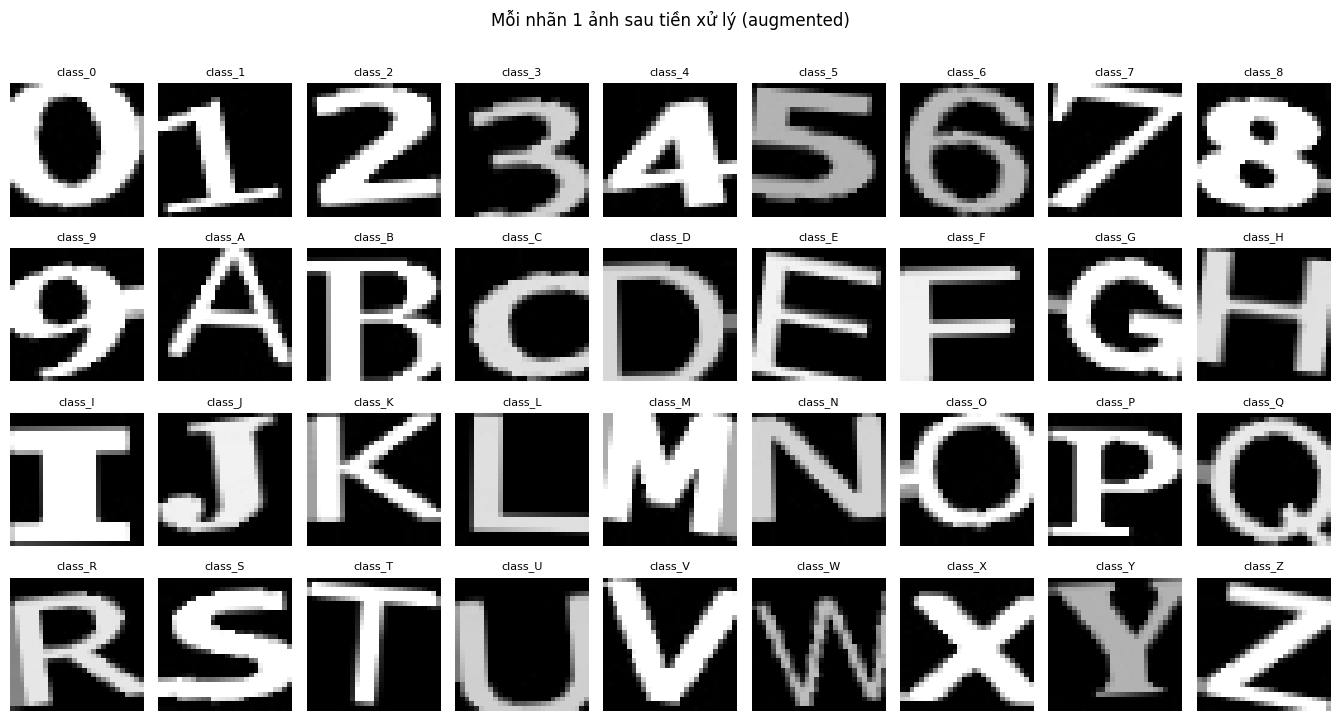

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

# ── Dataset path ──
path = '/kaggle/input/datasets/foolishboi/alpr-character-train/data'

# ── Data Generators ──
train_datagen = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=10,
    zoom_range=0.1,
    shear_range=0.1,
    brightness_range=[0.7, 1.3],
    horizontal_flip=False,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    path + '/train',
    target_size=(28, 28),
    batch_size=32,
    class_mode='sparse'
)
validation_generator = val_datagen.flow_from_directory(
    path + '/val',
    target_size=(28, 28),
    batch_size=32,
    class_mode='sparse'
)

print("Số class tìm được:", train_generator.num_classes)
print("Class indices:", train_generator.class_indices)

# ── Hiển thị ngẫu nhiên mỗi nhãn 1 ảnh sau khi tiền xử lý ──
class_indices = train_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
num_classes = train_generator.num_classes

# Lấy 1 batch lớn để đủ đại diện cho các class
images, labels = next(train_generator)

# Với mỗi nhãn, lấy ảnh đầu tiên tìm được trong batch
collected = {}
for img, lbl in zip(images, labels):
    cls = int(lbl)
    if cls not in collected:
        collected[cls] = img
    if len(collected) == num_classes:
        break

# Nếu batch đầu chưa đủ tất cả class, lấy thêm batch
while len(collected) < num_classes:
    images, labels = next(train_generator)
    for img, lbl in zip(images, labels):
        cls = int(lbl)
        if cls not in collected:
            collected[cls] = img
        if len(collected) == num_classes:
            break

# Vẽ lưới ảnh
cols = 9
rows = (num_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.8))
axes = axes.flatten()

for idx in range(num_classes):
    axes[idx].imshow(collected[idx])
    axes[idx].set_title(index_to_class[idx], fontsize=8)
    axes[idx].axis('off')

# Ẩn ô trống thừa
for idx in range(num_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Mỗi nhãn 1 ảnh sau tiền xử lý (augmented)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777772545.335400      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │        23,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 757,972 (2.89 MB)

 Trainable params: 757,620 (2.89 MB)

...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1777772550.189494     192 service.cc:152] XLA service 0x7cd93c015bc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777772550.189559     192 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777772550.872939     192 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/27 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.0642 - loss: 6.9862 

I0000 00:00:1777772556.486657     192 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.0454 - loss: 5.7160 - val_accuracy: 0.0729 - val_loss: 3.5452 - learning_rate: 1.0000e-04
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.1013 - loss: 3.3821 - val_accuracy: 0.0417 - val_loss: 3.5006 - learning_rate: 1.0000e-04
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1747 - loss: 3.0631 - val_accuracy: 0.0521 - val_loss: 3.4412 - learning_rate: 1.0000e-04
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.2714 - loss: 2.7126 - val_accuracy: 0.0990 - val_loss: 3.3223 - learning_rate: 1.0000e-04
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3580 - loss: 2.2443 - val_accuracy: 0.1510 - val_loss: 3.0609 - learning_rate: 1.0000e-04
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.4275 - loss: 1.9769 - val_accuracy: 0.3385 - val_loss: 2.7082 - learning_rate: 1.0000e-04
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4787 - loss: 1

Model đã được lưu: character_classifier_v2.h5


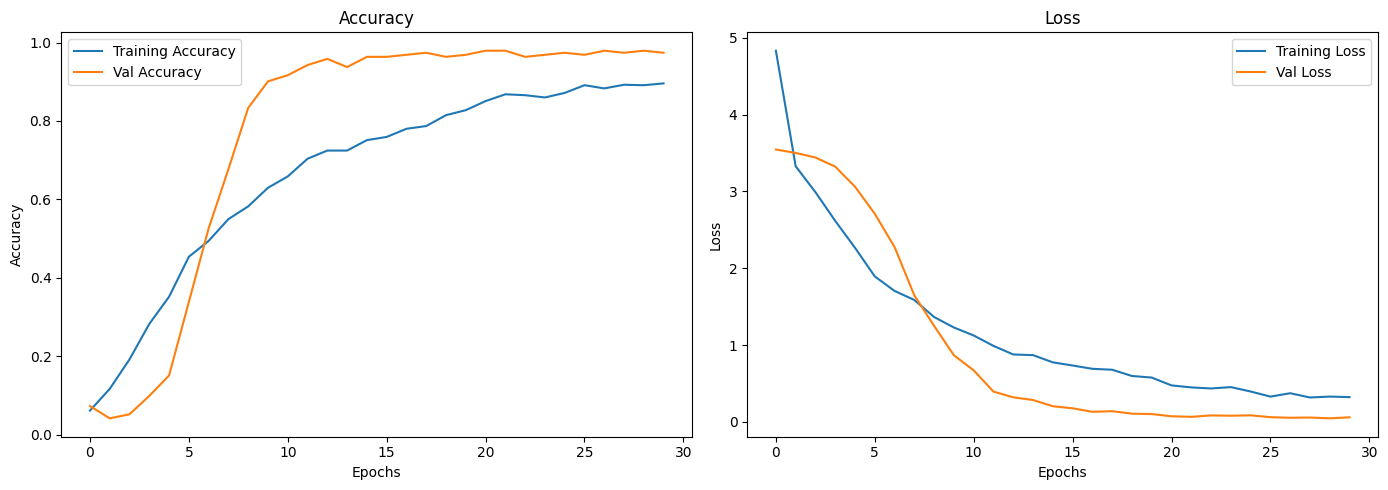

In [11]:
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Build Model ──
K.clear_session()
num_classes = train_generator.num_classes

model = Sequential([
    Conv2D(16, (22, 22), input_shape=(28, 28, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (16, 16), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (8, 8), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (4, 4), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(4, 4)),
    Dropout(0.4),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)
model.summary()

# ── Callbacks ──
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ── Train ──
result = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // 32,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

# ── Save model ──
model.save('character_classifier_v2.h5')
print("Model đã được lưu: character_classifier_v2.h5")

# ── Plot Accuracy & Loss ──
fig = plt.figure(figsize=(14, 5))
grid = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)

fig.add_subplot(grid[0])
plt.plot(result.history['accuracy'],     label='Training Accuracy')
plt.plot(result.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

fig.add_subplot(grid[1])
plt.plot(result.history['loss'],     label='Training Loss')
plt.plot(result.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
import os
model_path = os.path.abspath('character_classifier_v2.h5')
print(f"Đường dẫn chính xác của file model là: {model_path}")

Đường dẫn chính xác của file model là: /kaggle/working/character_classifier_v2.h5


Test 

In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import subprocess, sys

# Force cài đè vào đúng python đang chạy
subprocess.run([
    sys.executable, '-m', 'pip', 'install',
    'torch==2.4.1', 'torchvision==0.19.1',
    '--index-url', 'https://download.pytorch.org/whl/cu121',
    '--force-reinstall', '--no-deps', '-q'
], check=True)

# Kiểm tra ngay
result = subprocess.run(
    [sys.executable, '-c', 'import torch; print(torch.__version__)'],
    capture_output=True, text=True
)
print("Version sau cài:", result.stdout)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 2.3 MB/s eta 0:00:00
Version sau cài: 2.4.1+cu121



In [3]:
import torch
print(torch.__version__)  # Phải là 2.4.1, không phải 2.10

2.4.1+cu121


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

--- Đang xử lý: Dieu_0058.png ---

0: 480x640 1 class_0, 46.5ms
Speed: 6.9ms preprocess, 46.5ms inference, 16.9ms postprocess per image at shape (1, 3, 480, 640)


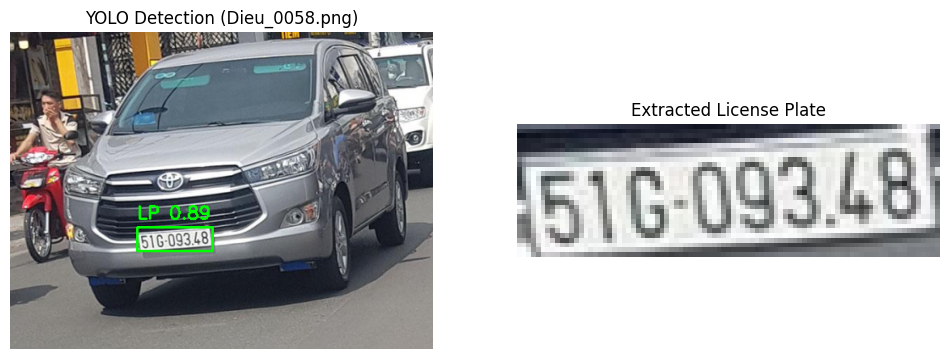

Contour Points:
[[[230 231]]

 [[150 237]]

 [[150 246]]

 [[153 237]]]

--- Đang xử lý: Dieu_0385.png ---

0: 640x480 1 class_1, 44.1ms
Speed: 2.3ms preprocess, 44.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


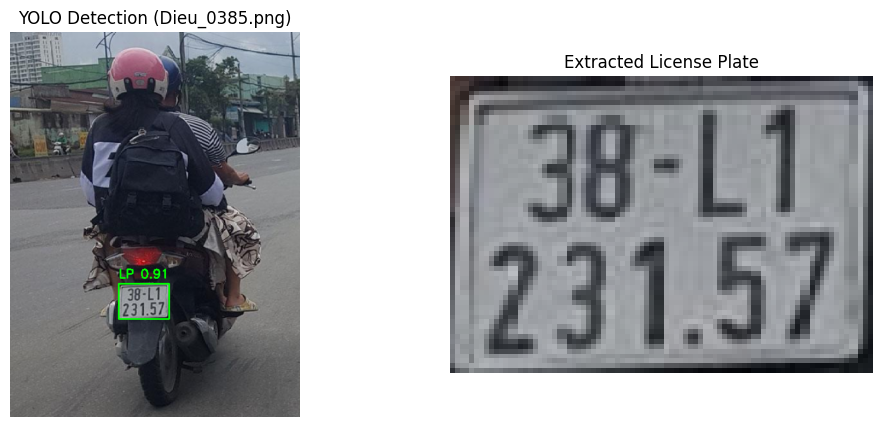

Contour Points:
[[[218 446]]

 [[218 451]]

 [[221 451]]

 [[221 446]]]


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutils
from ultralytics import YOLO

# 1. Load YOLO license plate detector
model = YOLO('/kaggle/input/datasets/trngngkhnh/weight/best_lp_detector.pt')

# 2. Danh sách các đường dẫn ảnh cần xử lý
image_paths = [
    '/kaggle/input/datasets/bikimhu/images-yolo/images/images/val/Dieu_0058.png',
    '/kaggle/input/datasets/bikimhu/images-yolo/images/images/val/Dieu_0385.png'
]

# 3. Vòng lặp xử lý từng ảnh
for path in image_paths:
    print(f"\n--- Đang xử lý: {path.split('/')[-1]} ---")
    
    # Đọc ảnh
    image = cv2.imread(path)
    if image is None:
        print(f" Không thể đọc được ảnh tại: {path}")
        continue
        
    # Resize ảnh
    image = imutils.resize(image, width=500)

    # YOLO detect biển số
    results = model(image)[0]
    ROI = None
    best_conf = 0.0
    best_box = None

    # Tìm box có confidence cao nhất
    if results.boxes is not None and len(results.boxes) > 0:
        for box in results.boxes:
            conf = float(box.conf[0])
            if conf > best_conf:
                best_conf = conf
                best_box = box

    # 4. Xử lý kết quả
    if best_box is not None:
        x1, y1, x2, y2 = map(int, best_box.xyxy[0])
        
        # Cắt ROI sạch (không dính khung)
        ROI = image[y1:y2, x1:x2].copy()

        # Tạo ảnh hiển thị có vẽ khung
        img_vis = image.copy()
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_vis, f'LP {best_conf:.2f}', (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Hiển thị Detection và ROI
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        ax[0].imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
        ax[0].set_title(f'YOLO Detection ({path.split("/")[-1]})')
        ax[0].axis('off')

        ax[1].imshow(cv2.cvtColor(ROI, cv2.COLOR_BGR2RGB))
        ax[1].set_title("Extracted License Plate")
        ax[1].axis('off')
        plt.show()

        # --- Phần xử lý Contour (Fine-tuning) ---
        roi_gray = cv2.cvtColor(ROI, cv2.COLOR_BGR2GRAY)
        roi_blur = cv2.GaussianBlur(roi_gray, (5, 5), 0)
        roi_edge = cv2.Canny(roi_blur, 50, 150)

        contours, _ = cv2.findContours(roi_edge, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        contours = sorted(contours, key=cv2.contourArea, reverse=True)

        NumberPlateCnt = None
        for cnt in contours:
            peri = cv2.arcLength(cnt, True)
            approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
            if len(approx) == 4:
                # Chuyển tọa độ từ ROI sang hệ tọa độ ảnh gốc
                approx[:, 0, 0] += x1
                approx[:, 0, 1] += y1
                NumberPlateCnt = approx
                break

        if NumberPlateCnt is None:
            print(" Không tìm được contour 4 góc, dùng bbox YOLO làm fallback.")
            NumberPlateCnt = np.array([
                [[x1, y1]], [[x2, y1]], [[x2, y2]], [[x1, y2]]
            ], dtype=np.int32)

        print(f"Contour Points:\n{NumberPlateCnt}")

    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title("No license plate detected")
        plt.axis('off')
        plt.show()
        print(" Không phát hiện được biển số.")


--- Đang xử lý: Dieu_0058.png ---

0: 480x640 1 class_0, 6.8ms
Speed: 2.4ms preprocess, 6.8ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


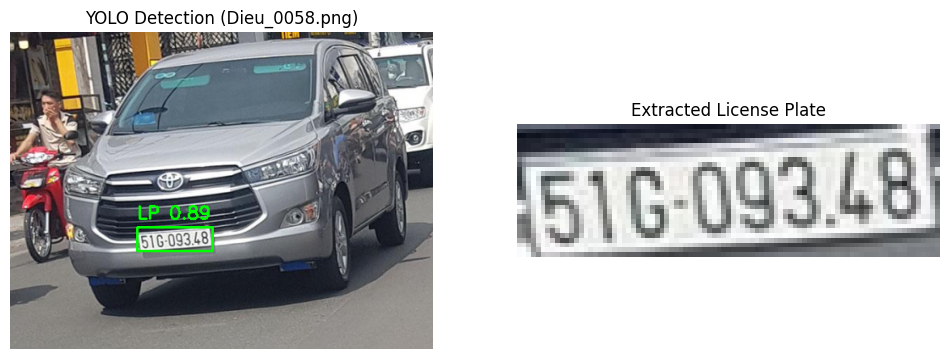

[Dieu_0058.png] Tìm được 8 ký tự – Bố cục: 1 hàng


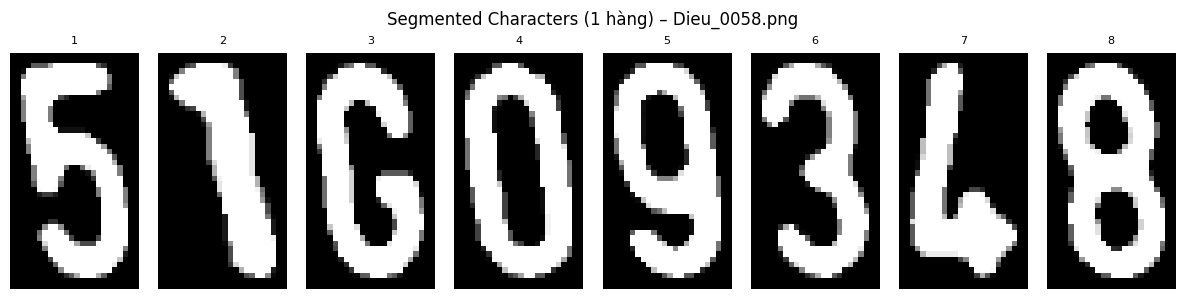


--- Đang xử lý: Dieu_0385.png ---

0: 640x480 1 class_1, 7.1ms
Speed: 3.0ms preprocess, 7.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


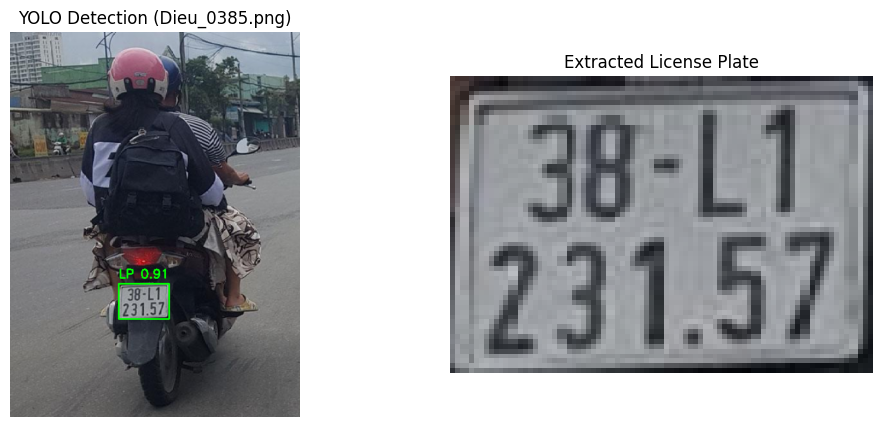

[Dieu_0385.png] Tìm được 9 ký tự – Bố cục: 2 hàng


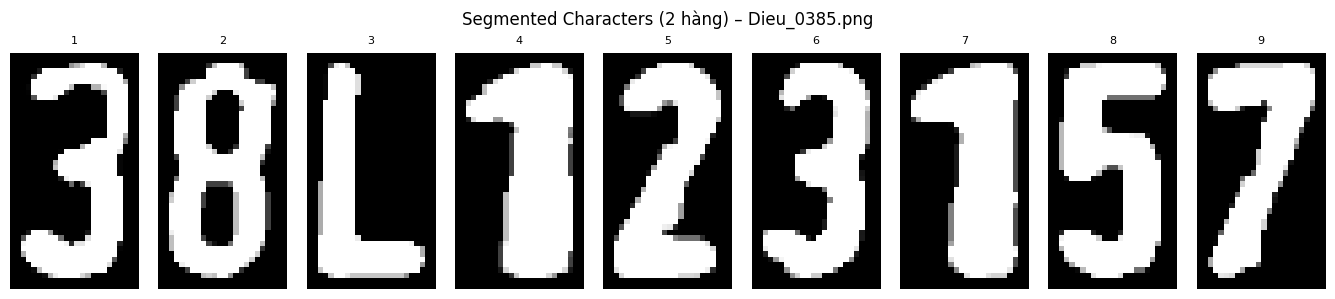

In [13]:
for path in image_paths:
    print(f"\n--- Đang xử lý: {path.split('/')[-1]} ---")

    image = cv2.imread(path)
    if image is None:
        print(f"Không thể đọc được ảnh tại: {path}")
        continue

    image = imutils.resize(image, width=500)
    results = model(image)[0]
    ROI = None
    best_conf = 0.0
    best_box = None

    if results.boxes is not None and len(results.boxes) > 0:
        for box in results.boxes:
            conf = float(box.conf[0])
            if conf > best_conf:
                best_conf = conf
                best_box = box

    if best_box is None:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title("No license plate detected")
        plt.axis('off')
        plt.show()
        print("Không phát hiện được biển số.")
        continue

    x1, y1, x2, y2 = map(int, best_box.xyxy[0])
    ROI = image[y1:y2, x1:x2].copy()

    img_vis = image.copy()
    cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img_vis, f'LP {best_conf:.2f}', (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
    ax[0].set_title(f'YOLO Detection ({path.split("/")[-1]})')
    ax[0].axis('off')
    ax[1].imshow(cv2.cvtColor(ROI, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Extracted License Plate")
    ax[1].axis('off')
    plt.show()

    # Contour fine-tuning logic (keeps NumberPlateCnt for coordinates)
    roi_gray = cv2.cvtColor(ROI, cv2.COLOR_BGR2GRAY)
    roi_blur = cv2.GaussianBlur(roi_gray, (5, 5), 0)
    roi_edge = cv2.Canny(roi_blur, 50, 150)
    contours, _ = cv2.findContours(roi_edge, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    NumberPlateCnt = None
    for cnt in contours:
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) == 4:
            approx[:, 0, 0] += x1
            approx[:, 0, 1] += y1
            NumberPlateCnt = approx
            break
    
    if NumberPlateCnt is None:
        NumberPlateCnt = np.array([[[x1, y1]], [[x2, y1]], [[x2, y2]], [[x1, y2]]], dtype=np.int32)

    # Orientation Check
    roi_h, roi_w = ROI.shape[:2]
    if roi_h > roi_w:
        ROI = cv2.rotate(ROI, cv2.ROTATE_90_COUNTERCLOCKWISE)

    result = ROI

    # BƯỚC 4: find_contours (Đã loại bỏ phần hiển thị Predict Segments)
    def find_contours(dimensions, img):
        cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        lower_width, upper_width = dimensions[0], dimensions[1]
        lower_height, upper_height = dimensions[2], dimensions[3]
        
        cntrs = sorted(cntrs, key=cv2.contourArea, reverse=True)[:20]
        img_res = []
        char_boxes = []
        
        for cntr in cntrs:
            intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)
            if (lower_width < intWidth < upper_width and lower_height < intHeight < upper_height):
                char_boxes.append((intX, intWidth, intY, intHeight))
                char_copy = np.zeros((44, 24))
                char = img[intY:intY+intHeight, intX:intX+intWidth]
                char = cv2.resize(char, (20, 40))
                # char = cv2.subtract(255, char)
                char_copy[2:42, 2:22] = char
                img_res.append(char_copy)
        
        # Đã xóa plt.imshow(ii) tại đây
        return img_res, char_boxes

    # --- Giữ nguyên các hàm bổ trợ bên trong vòng lặp ---
    def _compute_row_split(char_boxes, plate_h):
        if len(char_boxes) < 4: return False, plate_h // 2
        centers_y = sorted([y + h // 2 for (x, w, y, h) in char_boxes])
        max_gap, threshold_y = 0, plate_h // 2
        for i in range(1, len(centers_y)):
            gap = centers_y[i] - centers_y[i - 1]
            if gap > max_gap:
                max_gap = gap
                threshold_y = (centers_y[i] + centers_y[i - 1]) // 2
        return (max_gap > 0.25 * plate_h), threshold_y

    def sort_chars_reading_order(img_res, char_boxes, plate_h):
        is_two, threshold_y = _compute_row_split(char_boxes, plate_h)
        pairs = list(zip(char_boxes, img_res))
        if not is_two:
            pairs_sorted = sorted(pairs, key=lambda p: p[0][0])
        else:
            row1 = sorted([p for p in pairs if (p[0][2] + p[0][3] // 2) <= threshold_y], key=lambda p: p[0][0])
            row2 = sorted([p for p in pairs if (p[0][2] + p[0][3] // 2) > threshold_y], key=lambda p: p[0][0])
            pairs_sorted = row1 + row2
        return [p[1] for p in pairs_sorted], [p[0] for p in pairs_sorted], is_two, threshold_y

    def segment_characters(image):
        h, w = image.shape[:2]
        scale = 400 / max(h, w)
        img_lp = cv2.resize(image, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR)
        img_gray_lp = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY)
        img_gray_lp = cv2.GaussianBlur(img_gray_lp, (3, 3), 0)
        img_gray_lp = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4)).apply(img_gray_lp)
        _, img_binary_lp = cv2.threshold(img_gray_lp, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        LP_H, LP_W = img_binary_lp.shape[:2]
        # Xóa viền nhiễu
        img_binary_lp[0:5, :]=0; img_binary_lp[:, 0:5]=0; img_binary_lp[LP_H-5:, :]=0; img_binary_lp[:, LP_W-5:]=0
        
        dimensions = [LP_W / 20, LP_W / 3, LP_H / 5, LP_H * 0.9]
        img_res, char_boxes = find_contours(dimensions, img_binary_lp)
        return sort_chars_reading_order(img_res, char_boxes, LP_H)

    # BƯỚC 6: Gọi & hiển thị kết quả cuối cùng
    char, char_boxes, is_two_rows, threshold_y = segment_characters(result)
    layout = "2 hàng" if is_two_rows else "1 hàng"
    print(f"[{path.split('/')[-1]}] Tìm được {len(char)} ký tự – Bố cục: {layout}")

    if len(char) > 0:
        fig, axes = plt.subplots(1, len(char), figsize=(len(char) * 1.5, 3))
        if len(char) == 1: axes = [axes]
        for i, ax in enumerate(axes):
            ax.imshow(char[i], cmap='gray')
            ax.axis('off')
            ax.set_title(str(i + 1), fontsize=8)
        plt.suptitle(f'Segmented Characters ({layout}) – {path.split("/")[-1]}')
        plt.tight_layout()
        plt.show()

 Load character model thành công!

 Đang xử lý: Dieu_0058.png

0: 480x640 1 class_0, 7.0ms
Speed: 2.6ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


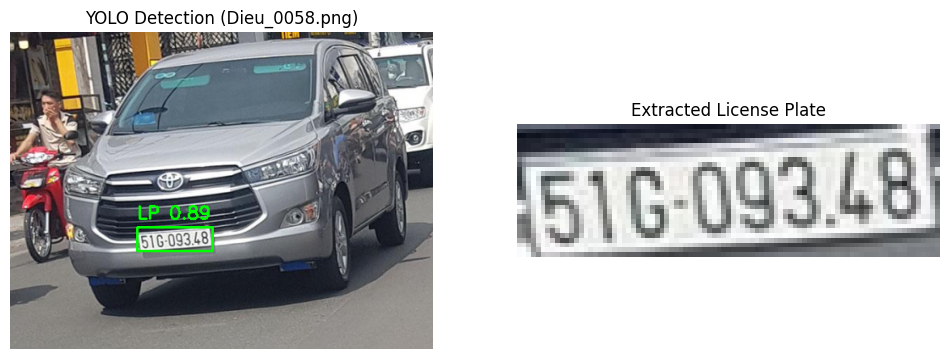

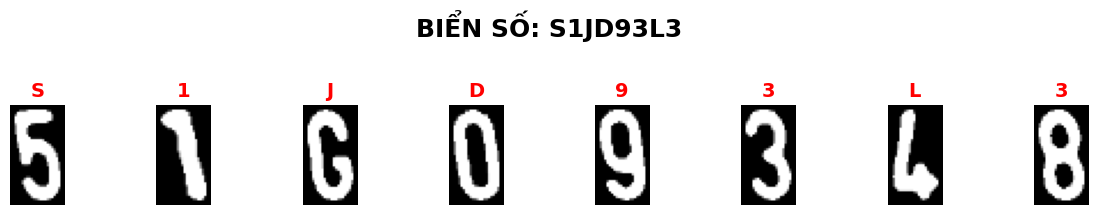

 Kết quả cuối cùng: S1JD93L3

 Đang xử lý: Dieu_0385.png

0: 640x480 1 class_1, 7.0ms
Speed: 2.4ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


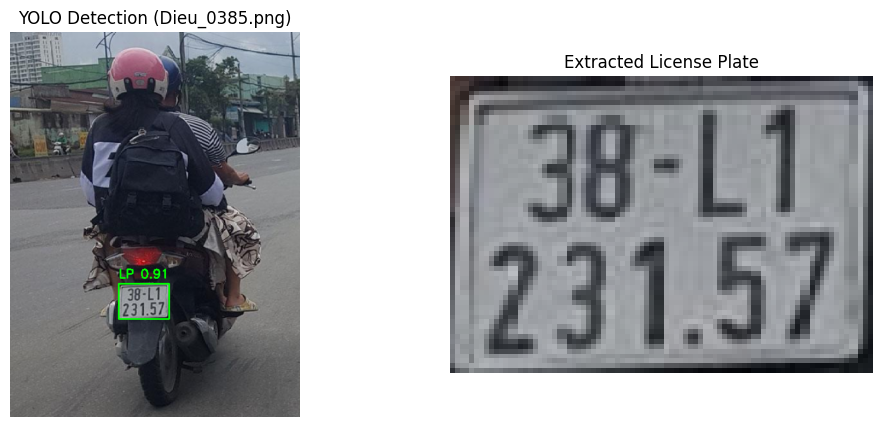

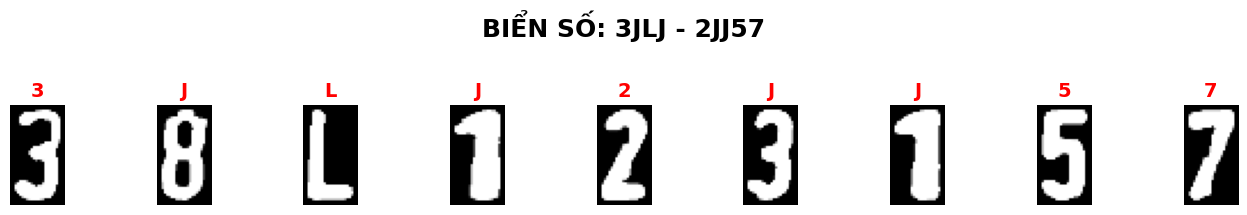

 Kết quả cuối cùng: 3JLJ | 2JJ57


In [14]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imutils
from tensorflow.keras.models import load_model

# 1. Load model nhận diện ký tự
KERAS_MODEL_PATH = '/kaggle/working/character_classifier_v2.h5'
if not os.path.exists(KERAS_MODEL_PATH):
    raise FileNotFoundError(f"Không tìm thấy model tại: {KERAS_MODEL_PATH}")
keras_model = load_model(KERAS_MODEL_PATH)
print(" Load character model thành công!")

# 2. Utility functions
def fix_dimension(img):
    new_img = np.zeros((28, 28, 3))
    for i in range(3):
        new_img[:, :, i] = img
    return new_img

def get_predictions(char_list, model):
    characters = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    dic = {i: c for i, c in enumerate(characters)}
    output = []
    for ch in char_list:
        img_ = cv2.resize(ch, (28, 28), interpolation=cv2.INTER_AREA)
        img = fix_dimension(img_)
        img = img.reshape(1, 28, 28, 3)
        y_prob = model.predict(img, verbose=0)
        y_ = np.argmax(y_prob, axis=1)[0]
        output.append(dic[y_])
    return output

def build_display_text(char_boxes, predictions, is_two_rows, threshold_y):
    if not is_two_rows:
        plate_text = "".join(predictions)
        fontsize = 18
    else:
        row1_chars = [p for p, box in zip(predictions, char_boxes) if (box[2] + box[3] // 2) <= threshold_y]
        row2_chars = [p for p, box in zip(predictions, char_boxes) if (box[2] + box[3] // 2) > threshold_y]
        plate_text = f"{''.join(row1_chars)}\n{''.join(row2_chars)}"
        fontsize = 14
    return plate_text, fontsize

# 3. Vòng lặp xử lý từng ảnh
for path in image_paths:
    filename = path.split('/')[-1]
    print(f"\n Đang xử lý: {filename}")

    image = cv2.imread(path)
    if image is None: continue
    image = imutils.resize(image, width=500)

    # YOLO detect
    results = model(image)[0]
    best_conf, best_box = 0.0, None

    if results.boxes is not None and len(results.boxes) > 0:
        for box in results.boxes:
            conf = float(box.conf[0])
            if conf > best_conf:
                best_conf, best_box = conf, box

    if best_box is None:
        print(f" Không phát hiện được biển số trong {filename}")
        continue

    # Cắt ROI sạch
    x1, y1, x2, y2 = map(int, best_box.xyxy[0])
    ROI = image[y1:y2, x1:x2].copy()

    # --- HIỂN THỊ PHẦN 1: DETECTION & EXTRACTED ---
    img_vis = image.copy()
    cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img_vis, f'LP {best_conf:.2f}', (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
    ax[0].set_title(f'YOLO Detection ({filename})')
    ax[0].axis('off')
    ax[1].imshow(cv2.cvtColor(ROI, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Extracted License Plate")
    ax[1].axis('off')
    plt.show()

    # Xoay (Orientation check)
    roi_h, roi_w = ROI.shape[:2]
    if roi_h > roi_w:
        ROI = cv2.rotate(ROI, cv2.ROTATE_90_COUNTERCLOCKWISE)

    # Phân đoạn ký tự (segment_characters cần được định nghĩa trước đó)
    char, char_boxes, is_two_rows, threshold_y = segment_characters(ROI)

    if len(char) == 0:
        print(" Không tách được ký tự nào.")
        continue

    # Nhận diện chữ
    predictions = get_predictions(char, keras_model)
    plate_text, fontsize = build_display_text(char_boxes, predictions, is_two_rows, threshold_y)

    # --- HIỂN THỊ PHẦN 2: TỪNG KÝ TỰ & BIỂN SỐ CUỐI CÙNG ---
    n = len(char)
    cols = min(n, 9) # Tăng số cột để hiển thị gọn hơn
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(cols * 1.5, rows * 2))
    for i, ch in enumerate(char):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(ch, cmap='gray')
        plt.title(predictions[i], fontsize=14, fontweight='bold', color='red')
        plt.axis('off')

    plt.suptitle(f'BIỂN SỐ: {plate_text.replace(chr(10), " - ")}',
                 fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    print(f" Kết quả cuối cùng: {plate_text.replace(chr(10), ' | ')}")